In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler,OneHotEncoder
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor,GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
%matplotlib inline
plt.rcParams['figure.figsize']=(10,5)
plt.rcParams['figure.dpi']=250

In [40]:
data = pd.read_csv("Maha_Agri.csv")

In [41]:
data.head(10)

,District,Crop,Year,Season,Area,Production,Yield
0,NANDED,Castor seed,2015-16,Kharif,10.0,1.0,0.10
1,SINDHUDURG,Castor seed,2015-16,Kharif,5.0,1.0,0.20
2,LATUR,Groundnut,2015-16,Summer,8.0,1.0,0.13
3,NANDED,Linseed,2015-16,Rabi,10.0,1.0,0.10
4,GADCHIROLI,Moong(Green Gram),2015-16,Summer,3.0,1.0,0.33
5,JALNA,Niger seed,2015-16,Kharif,20.0,1.0,0.05
6,RATNAGIRI,Sesamum,2015-16,Rabi,2.0,1.0,0.50
7,SINDHUDURG,Sesamum,2015-16,Rabi,2.0,1.0,0.50
8,DHULE,Sunflower,2015-16,Rabi,5.0,1.0,0.20
9,SINDHUDURG,Sunflower,2015-16,Rabi,5.0,1.0,0.20


# we are only keeping the records of - Kharif and Rabi Season.
# We have Removed the records of - Whole Year and Summer.

In [42]:
# 1. Keep only Kharif and Rabi seasons
filtered_data = data[data["Season"].isin(["Kharif", "Rabi"])]

filtered_data.head(10)

,District,Crop,Year,Season,Area,Production,Yield
0,NANDED,Castor seed,2015-16,Kharif,10.0,1.0,0.10
1,SINDHUDURG,Castor seed,2015-16,Kharif,5.0,1.0,0.20
3,NANDED,Linseed,2015-16,Rabi,10.0,1.0,0.10
5,JALNA,Niger seed,2015-16,Kharif,20.0,1.0,0.05
6,RATNAGIRI,Sesamum,2015-16,Rabi,2.0,1.0,0.50
7,SINDHUDURG,Sesamum,2015-16,Rabi,2.0,1.0,0.50
8,DHULE,Sunflower,2015-16,Rabi,5.0,1.0,0.20
9,SINDHUDURG,Sunflower,2015-16,Rabi,5.0,1.0,0.20
10,PUNE,Castor seed,2018-19,Kharif,3.0,1.0,0.33
12,GADCHIROLI,Moong(Green Gram),2018-19,Kharif,10.0,1.0,0.10


In [43]:
print("\nData Types:")
print(filtered_data.dtypes)
print("\n================================")
print("\nDataset Shape:\n")
print(filtered_data.shape)
print("\n================================")
print("\nMissing Values:\n")
print(filtered_data.isnull().sum())


Data Types:
District       object
Crop           object
Year           object
Season         object
Area          float64
Production    float64
Yield         float64
dtype: object


Dataset Shape:

(1845, 7)


Missing Values:

District      0
Crop          0
Year          0
Season        0
Area          0
Production    0
Yield         0
dtype: int64


In [44]:
filtered_data.describe()

,Area,Production,Yield
count,1845.000000,1.845000e+03,1845.000000
mean,30954.941789,4.125727e+04,0.798081
std,73698.013486,1.042428e+05,0.748561
min,0.500000,1.000000e+00,0.010000
25%,100.000000,3.000000e+01,0.250000
50%,300.000000,1.000000e+02,0.500000
75%,29100.000000,3.440000e+04,1.030000
max,765000.000000,1.097100e+06,7.890000


In [45]:
filtered_data.groupby("Crop")["Yield"].mean().sort_values(ascending=False)

Crop
Maize                2.163860
Cotton(lint)         1.687922
Wheat                1.649011
Soyabean             1.426667
Rice                 1.399855
Jowar                1.007923
Ragi                 1.005769
Groundnut            0.890392
Gram                 0.826364
Small millets        0.658319
Bajra                0.652549
Safflower            0.598947
Arhar/Tur            0.571379
Urad                 0.526667
Moong(Green Gram)    0.455417
Sunflower            0.419013
Rapeseed &Mustard    0.381913
Castor seed          0.325364
Linseed              0.311852
Sesamum              0.302915
Niger seed           0.181860
Name: Yield, dtype: float64

In [46]:
filtered_data.groupby("District")["Area"].mean().sort_values(ascending=False)

District
OSMANABAD     66952.388889
JALGAON       55828.586207
YAVATMAL      54635.000000
AURANGABAD    49663.683333
AMRAVATI      48036.446809
SOLAPUR       46069.128205
LATUR         45662.380000
BULDHANA      45130.763636
NAGPUR        44795.932203
BEED          42405.238806
NASHIK        36961.228070
AHMEDNAGAR    35916.697368
PUNE          33594.732143
DHULE         31579.075472
PARBHANI      30908.445946
AKOLA         30488.316667
NANDED        30086.688312
JALNA         29741.265625
CHANDRAPUR    26333.636364
SANGLI        24487.692308
WASHIM        24330.022727
WARDHA        23999.690476
HINGOLI       23710.602740
THANE         21344.758065
KOLHAPUR      17075.187500
SATARA        16981.058824
RAIGAD        15458.100000
GADCHIROLI    14531.681818
NANDURBAR     12720.698630
GONDIA        10666.529412
BHANDARA       9961.794872
SINDHUDURG     6081.457143
RATNAGIRI      4466.875000
PALGHAR         119.807692
Name: Area, dtype: float64

In [47]:
filtered_data['District'].value_counts()

SATARA        85
SOLAPUR       78
NANDED        77
AHMEDNAGAR    76
PARBHANI      74
HINGOLI       73
NANDURBAR     73
BEED          67
SANGLI        65
JALNA         64
AURANGABAD    60
NAGPUR        59
JALGAON       58
NASHIK        57
PUNE          56
CHANDRAPUR    55
BULDHANA      55
AKOLA         54
DHULE         53
YAVATMAL      50
LATUR         50
KOLHAPUR      48
AMRAVATI      47
GADCHIROLI    44
WASHIM        44
WARDHA        42
RAIGAD        40
RATNAGIRI     40
BHANDARA      39
OSMANABAD     36
SINDHUDURG    35
GONDIA        34
THANE         31
PALGHAR       26
Name: District, dtype: int64

In [48]:
filtered_data["District"].nunique()

34

In [49]:
# Data Cleaning

In [50]:
# Filtering the Data
data_kharif = filtered_data[(filtered_data['Season'] == 'Kharif') & (filtered_data['Area'] > 100) & (filtered_data['Production'] > 100)].sort_values(by='Year')
data_rabi = filtered_data[(filtered_data['Season'] == 'Rabi') & (filtered_data['Area'] > 100) & (filtered_data['Production'] > 100)].sort_values(by='Year')

In [51]:
# Handle outliers (for numerical columns)
def handle_outliers(df, columns):
    for col in columns:
        if col in df.select_dtypes(include=np.number).columns:
            q1 = df[col].quantile(0.25)
            q3 = df[col].quantile(0.75)
            iqr = q3 - q1
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr

    return lower_bound,upper_bound

In [52]:
kharif_out = handle_outliers(data_kharif,['Yield'])
rabi_out  = handle_outliers(data_rabi,['Yield'])

print("Kharif Upper and Lower Limit")
print(f"Lower Bound : {kharif_out[0]}")
print(f"Upper Bound : {kharif_out[1]}")
print("====================================================")
print("Rabi Upper and Lower Limit")
print(f"Lower Bound : {rabi_out[0]}")
print(f"Upper Bound : {rabi_out[1]}")


Kharif Upper and Lower Limit
Lower Bound : -0.98375
Upper Bound : 3.42625
Rabi Upper and Lower Limit
Lower Bound : -0.7237500000000001
Upper Bound : 3.2262500000000003


In [53]:
kharif_outliers = data_kharif[(data_kharif['Yield'] < kharif_out[0]) | (data_kharif['Yield'] > kharif_out[1])]
rabi_outliers = data_rabi[(data_rabi['Yield'] < rabi_out[0]) | (data_rabi['Yield'] > rabi_out[1])]
print(f"Total Records of Kharif Dataset : {data_kharif.shape}")
print(f"Total Records of Rabi Dataset : {data_rabi.shape}")
print("="*40)
print(f"Total outliers in Kharif dataset: {len(kharif_outliers)}")
print(f"Total outliers in Rabi dataset: {len(rabi_outliers)}")

Total Records of Kharif Dataset : (452, 7)
Total Records of Rabi Dataset : (268, 7)
Total outliers in Kharif dataset: 3
Total outliers in Rabi dataset: 4


In [58]:
print(kharif_outliers)
print(rabi_outliers)

        District          Crop     Year  Season      Area  Production  Yield
702   AURANGABAD         Maize  2010-11  Kharif  138400.0    508200.0   3.67
712      JALGAON         Maize  2011-12  Kharif   65000.0    235100.0   3.62
1925  GADCHIROLI  Cotton(lint)  2017-18  Kharif    5654.0     22600.0   4.00
        District   Crop     Year Season     Area  Production  Yield
1982  AURANGABAD  Maize  2016-17   Rabi  16000.0     52800.0   3.30
1990        PUNE  Maize  2016-17   Rabi  22400.0    176700.0   7.89
1986       DHULE  Maize  2017-18   Rabi   5600.0     19500.0   3.48
2084       JALNA  Maize  2019-20   Rabi   2398.0      9204.0   3.84


In [59]:
# Remove outliers 

data_kharif_clean = data_kharif.drop(kharif_outliers.index, errors='ignore').reset_index(drop=True)
data_rabi_clean = data_rabi.drop(rabi_outliers.index, errors='ignore').reset_index(drop=True)

# Combine both datasets
df_clean = pd.concat([data_kharif_clean, data_rabi_clean], ignore_index=True)

# Optional: sort by Year or any other column
df_clean = df_clean.sort_values(by='Year').reset_index(drop=True)

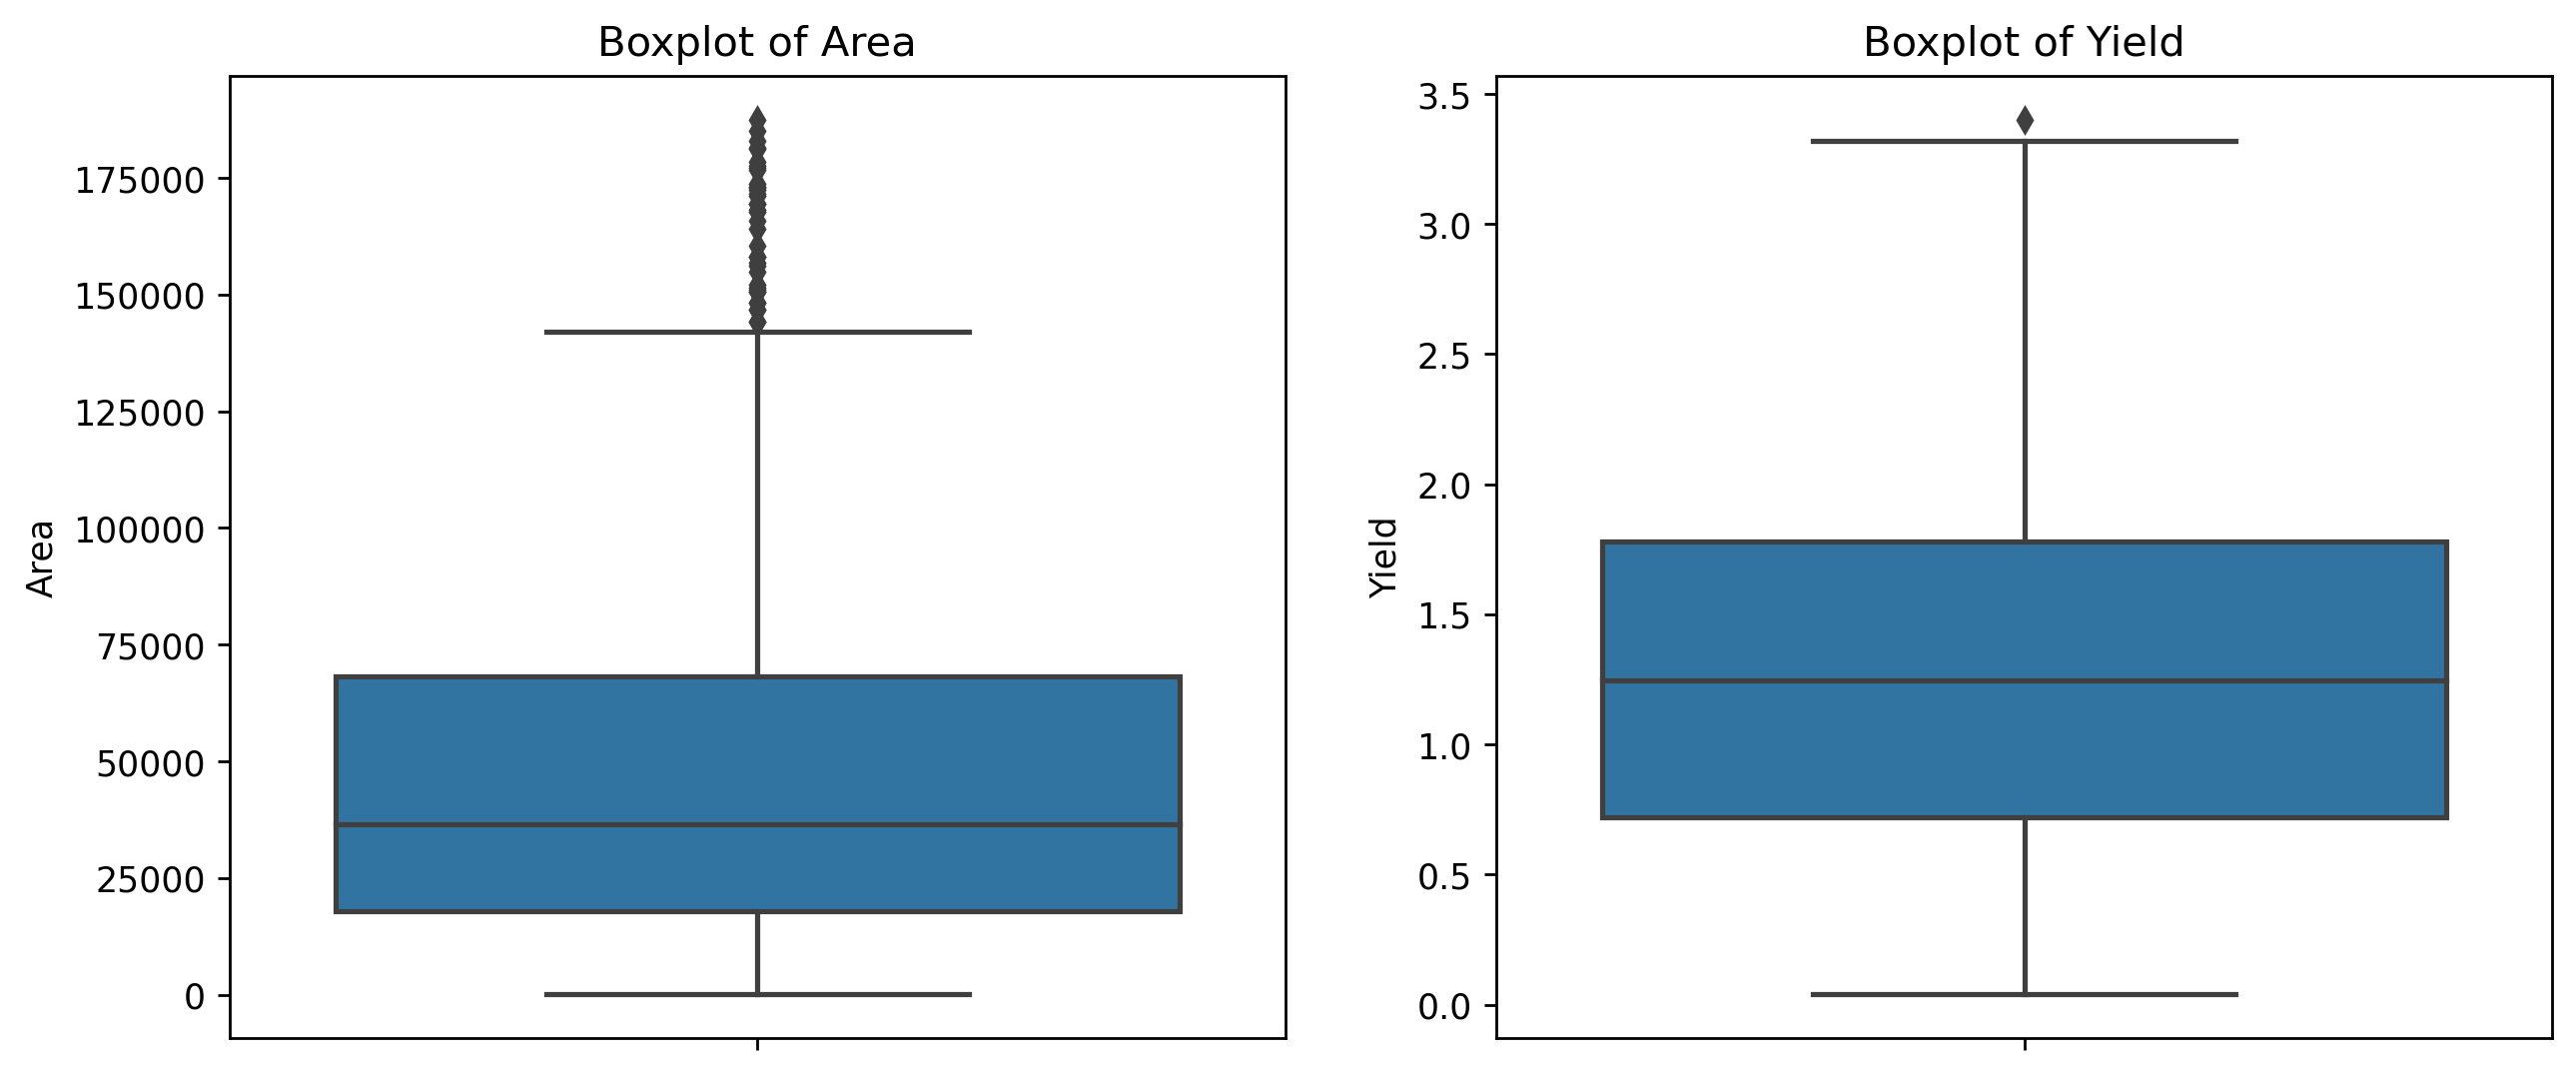

In [60]:


# Boxplots after outlier handling
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(y=df_clean["Area"])
plt.title("Boxplot of Area")

plt.subplot(1,2,2)
sns.boxplot(y=df_clean["Yield"])
plt.title("Boxplot of Yield")
plt.show()


In [18]:
# Data Visualization

In [61]:
# ==============================
# District-Wise Crop Production
# ==============================
# Unique districts
districts = df_clean['District'].unique()
n_districts = len(districts)

import math
# Define subplot grid
cols = 3
rows = math.ceil(n_districts / cols)


fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))
axes = axes.flatten()


# Loop through each district and plot crops vs production
for i, district in enumerate(districts):
  district_data = df_clean[df_clean['District'] == district]
  sns.barplot(x='Crop', y='Production', data=district_data,ci=None, ax=axes[i])
  axes[i].set_title(f"{district}", fontsize=14)
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90)
  axes[i].set_ylabel("Total Production")
  axes[i].set_xlabel("Crop")


# Hide any unused subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])


plt.tight_layout()
plt.savefig("District-Wise Crop Distribution(remove_out).jpg")
plt.show()

# we have plotted all the crops based on all the districts of maharashtra.
# here the values of production are fluctuating for some crops like, in sindhudurg district the values are - 100000 to 600000 and others have values between 0.0 to 4.

In [62]:
#  Drop 'Production' since not required
df_clean = df_clean.drop(columns=["Production"])
df_clean.head(10)

,District,Crop,Year,Season,Area,Yield
0,AURANGABAD,Bajra,2010-11,Kharif,89800.0,1.41
1,BHANDARA,Small millets,2010-11,Rabi,11500.0,1.09
2,BULDHANA,Small millets,2010-11,Rabi,82800.0,1.58
3,CHANDRAPUR,Small millets,2010-11,Rabi,40400.0,0.99
4,DHULE,Small millets,2010-11,Rabi,42500.0,2.09
5,HINGOLI,Small millets,2010-11,Rabi,60600.0,1.24
6,KOLHAPUR,Small millets,2010-11,Rabi,29700.0,2.01
7,LATUR,Small millets,2010-11,Rabi,66800.0,1.09
8,NAGPUR,Small millets,2010-11,Rabi,78500.0,1.49
9,NANDED,Small millets,2010-11,Rabi,78600.0,1.42


In [63]:
# Feature selection and preprocessing
target = 'Yield'
features = df_clean.drop(columns=[target])

In [64]:
# Separate categorical and numerical columns
categorical_columns = features.select_dtypes(include=['object']).columns
numerical_columns = features.select_dtypes(include=['int64', 'float64']).columns

In [65]:
# Encode categorical data
encoder = OneHotEncoder(handle_unknown='ignore')
categorical_encoded = encoder.fit_transform(features[categorical_columns]).toarray()
categorical_feature_names = encoder.get_feature_names_out(categorical_columns)

In [66]:
# Scale numerical data
scaler = StandardScaler()
numerical_scaled = scaler.fit_transform(features[numerical_columns])

In [67]:
# Combine processed features
X_processed = np.hstack((numerical_scaled, categorical_encoded))
feature_names = list(numerical_columns) + list(categorical_feature_names)

In [75]:
X = X_processed
y = df_clean[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [76]:
# Function for all evaluation metrics
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [77]:
# Making a list of all the models we are going to use
models = {
    "Linear Regression": LinearRegression(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(random_state=42),
    "XGBRegressor": XGBRegressor(random_state=42),
    "AdaBoost Regressor": AdaBoostRegressor(random_state=42)
}
model_list = []
r2_list =[]

In [78]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)


    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')

    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)

    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 0.3639
- Mean Absolute Error: 0.2795
- R2 Score: 0.7698
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.3789
- Mean Absolute Error: 0.2800
- R2 Score: 0.7096


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 0.3805
- Mean Absolute Error: 0.2842
- R2 Score: 0.7483
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.4036
- Mean Absolute Error: 0.3121
- R2 Score: 0.6705


Decision Tree
Model performance for Training set
- Root Mean Squared Error: 0.0000
- Mean Absolute Error: 0.0000
- R2 Score: 1.0000
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.4638
- Mean Absolute Error: 0.3574
- R2 Score: 0.5649


Random Forest Regressor
Model performance for Training set
- Root Mean Squared Error: 0.1594
- Mean Absolute Error: 0.1159
- R2 Score: 0.95

In [79]:
# Find the best model based on R2 score
best_model_index = r2_list.index(max(r2_list))
best_model_name = model_list[best_model_index]
best_model = list(models.values())[best_model_index]

print(f"Best Model: {best_model_name}")

# Use the best model to make predictions on the test set
y_pred_best_model = best_model.predict(X_test)

# Evaluate the best model
mae_best, rmse_best, r2_best = evaluate_model(y_test, y_pred_best_model)

print('\nModel performance for Test set (Best Model)')
print("- Root Mean Squared Error: {:.4f}".format(rmse_best))
print("- Mean Absolute Error: {:.4f}".format(mae_best))
print("- R2 Score: {:.4f}".format(r2_best))

Best Model: Random Forest Regressor

Model performance for Test set (Best Model)
- Root Mean Squared Error: 0.3543
- Mean Absolute Error: 0.2701
- R2 Score: 0.7461


In [80]:
score = r2_best*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 74.61


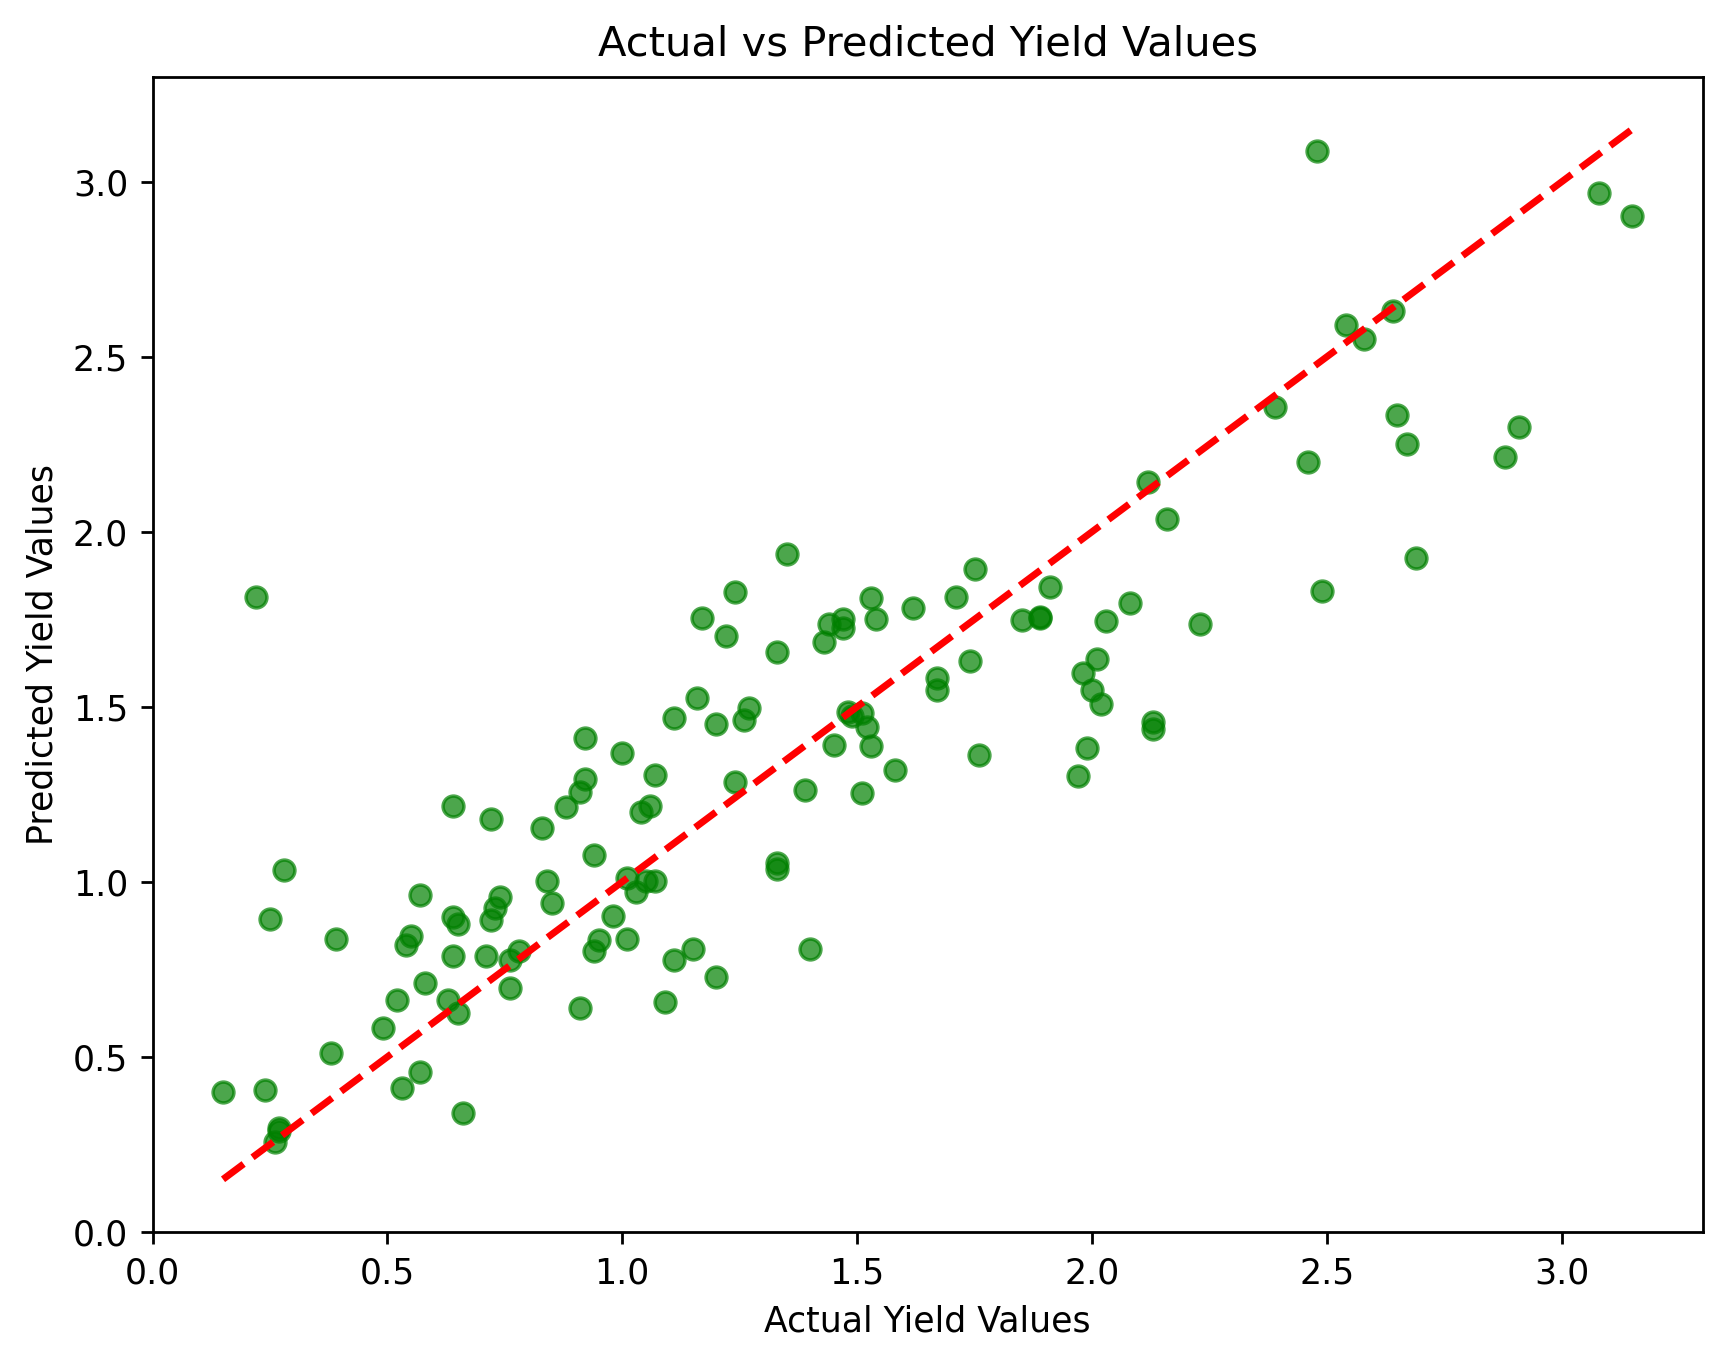

In [81]:
# Visualization of predictions vs actual values for the last model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best_model, alpha=0.7, color='g')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel('Actual Yield Values')
plt.ylabel('Predicted Yield Values')
plt.title('Actual vs Predicted Yield Values')
plt.show()

In [82]:
pred_values=pd.DataFrame({'Actual Yield Value':y_test,'Predicted Yield Value':y_pred_best_model})
pred_values

,Actual Yield Value,Predicted Yield Value
249,1.67,1.5823
399,1.45,1.3918
174,1.20,1.4509
280,2.02,1.5069
110,2.88,2.2140
...,...,...
6,2.01,1.6355
104,2.13,1.4570
114,1.48,1.4842
354,2.39,2.3554
